# Notebook support pour un projet ML supervisé (classification)
## Notebook 3 - Première modélisation

Pour introduire cette phase de modélisation, il est important de clarifier l’objectif prioritaire des modèles que nous allons développer.

D’un point de vue métier, l’enjeu principal est de limiter les faux négatifs, c’est-à-dire les salariés réellement à risque de départ que le modèle ne détecte pas.  
En effet, un départ non anticipé peut engendrer des coûts significatifs pour l’entreprise : recrutement, intégration, perte de productivité, perte de connaissances métier et désorganisation des équipes.

Dans ce contexte, le rappel (`Recall`) sur la classe positive nous apparaît comme la métrique à privilégier pour orienter la sélection et l’optimisation des modèles.

Commençons par charger les données de sortie de la phase de feature engineering.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

#import des données : 
df_MODEL = pd.read_csv("../data/processed/df_MODEL.csv")
df_MODEL.shape



(1470, 60)

In [4]:
print("a_quitte_l_entreprise" in df_MODEL.columns)
print(df_MODEL.columns.tolist())

True
['id_employee', 'age', 'genre', 'nombre_experiences_precedentes', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'revenu_mensuel_log', 'annee_experience_totale_log', 'annees_dans_l_entreprise_log', 'annees_dans_le_poste_actuel_log', 'annees_depuis_la_derniere_promotion_log', 'annes_sous_responsable_actuel_log', 'distance_domicile_travail_classe', 'ratio_anciennete_poste', 'ratio_anciennete_manager', 'ratio_experience_entreprise', 'mobilite_interne_potentielle', 'jamais_promu', 'retard_promotion_relatif', 'progression_salariale_faible', 'mediane_revenu_par_niveau', 'revenu_par_niveau', 'sous_remunere_nive

## Séparation du jeu de données en : train/test (80 %) pour la CV + test final (20 %)

**N.B. :** Nous excluons volontairement le travail de feature engineering dans cette première phase de modélisation.


In [30]:
# Separation des variables explicatives et de la cible
target = "a_quitte_l_entreprise"

nouvelles_cols = [
    "ratio_anciennete_poste",
    "ratio_anciennete_manager",
    "ratio_experience_entreprise",
    "mobilite_interne_potentielle",
    "retard_promotion_relatif",
    "revenu_par_niveau",
    "revenu_par_poste",
    "evolution_evaluation",
    "bonne_perf_peu_augmente",
]

X = df_MODEL.drop(columns=[target])
y = df_MODEL[target]

# Split : 80 % train (pour CV) / 20 % test final
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=4,stratify=y)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1176, 59)
X_test  : (294, 59)
y_train : (1176,)
y_test  : (294,)


## Tests des premiers modèles



Dummy
Train | Accuracy: 0.8384 +/- 0.0001 | Precision: 0.0000 +/- 0.0000 | Recall: 0.0000 +/- 0.0000 | F1: 0.0000 +/- 0.0000 | ROC AUC: 0.5000 +/- 0.0000 | PR-AUC: 0.1616 +/- 0.0001
Test  | Accuracy: 0.8384 +/- 0.0003 | Precision: 0.0000 +/- 0.0000 | Recall: 0.0000 +/- 0.0000 | F1: 0.0000 +/- 0.0000 | ROC AUC: 0.5000 +/- 0.0000 | PR-AUC: 0.1616 +/- 0.0003
Temps | Total CV: 0.2418s | Moyenne par fold: 0.0017s +/- 0.0006s


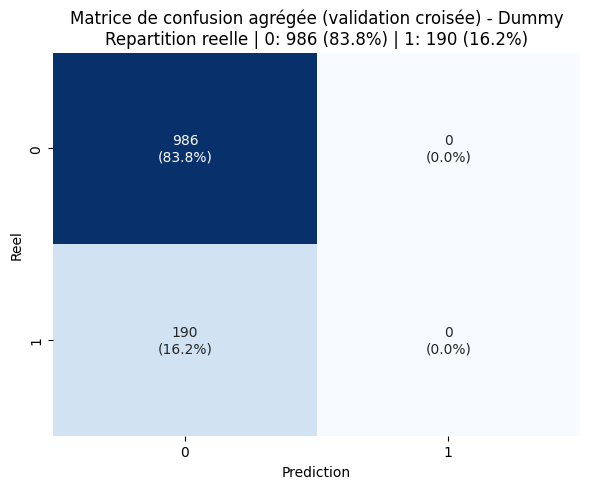


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91       986
         1.0       0.00      0.00      0.00       190

    accuracy                           0.84      1176
   macro avg       0.42      0.50      0.46      1176
weighted avg       0.70      0.84      0.76      1176


Logistic Regression
Train | Accuracy: 0.7993 +/- 0.0076 | Precision: 0.4346 +/- 0.0123 | Recall: 0.8026 +/- 0.0232 | F1: 0.5638 +/- 0.0141 | ROC AUC: 0.8846 +/- 0.0070 | PR-AUC: 0.6856 +/- 0.0276
Test  | Accuracy: 0.7602 +/- 0.0216 | Precision: 0.3712 +/- 0.0385 | Recall: 0.7053 +/- 0.0990 | F1: 0.4859 +/- 0.0558 | ROC AUC: 0.8141 +/- 0.0428 | PR-AUC: 0.5951 +/- 0.0687
Temps | Total CV: 0.3254s | Moyenne par fold: 0.0309s +/- 0.0058s


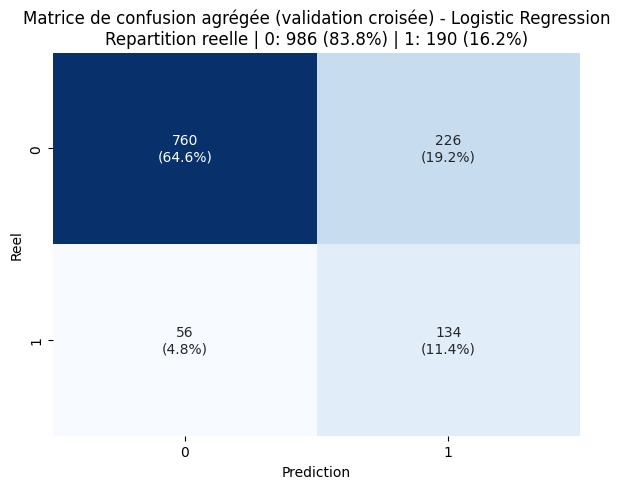


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84       986
         1.0       0.37      0.71      0.49       190

    accuracy                           0.76      1176
   macro avg       0.65      0.74      0.67      1176
weighted avg       0.84      0.76      0.79      1176



In [32]:
import importlib
import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=3000,random_state=42,class_weight="balanced")),
    ]),
}

for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_train,y=y_train,cv=5,stratify=True,model_name=name,)


## Premiers résultats de modélisation

### Dummy
Le modèle Dummy confirme qu’une accuracy élevée ne suffit pas à juger la performance dans un contexte de cible déséquilibrée.  
En prédisant systématiquement la classe majoritaire, il atteint environ 83 % d’accuracy, mais son rappel, sa précision et son score F1 sont nuls.  
Il ne détecte donc aucun départ et ne présente aucun intérêt opérationnel.

### Logistic Regression
La régression logistique constitue ici la baseline la plus équilibrée.  
Elle améliore nettement l’ensemble des métriques par rapport au Dummy, avec un bon pouvoir discriminant global (`PR AUC = 0,5951` sur les folds de test).  
Surtout, elle détecte une part significative des départs (`Recall = 0,7053` sur les folds de test), ce qui est cohérent avec l’objectif métier prioritaire.  
L’écart-type sur le rappel (`std Recall = 0,0990`) montre toutefois une stabilité encore faible selon les folds.
Même si ce rappel reste perfectible, le modèle linéaire offre à ce stade le meilleur compromis entre détection des départs et stabilité de généralisation.
